<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week5Day5DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn**

Importing of Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

Loading Dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving US Superstore data (2).xls to US Superstore data (2).xls


In [7]:
import pandas as pd

df = pd.read_excel("/content/US Superstore data (2).xls")

Data Cleaning

In [8]:
# Check the shape
df.shape

# View data types
df.info()

# Check for missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create a Year column
df["Year"] = df["Order Date"].dt.year

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Data Visualization with Matplotlib

In [9]:
# Make sure Order Date is formatted correctly
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Remove rows where the date could not be converted
df = df.dropna(subset=["Order Date"])

# Create the Year column
df["Year"] = df["Order Date"].dt.year

# Calculate total sales for each year
sales_year = (
    df.groupby("Year", as_index=False)["Sales"]
      .sum()
      .sort_values("Year")
)

print(sales_year)

# Create the chart
plt.figure(figsize=(10, 6))

plt.plot(
    sales_year["Year"],
    sales_year["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Sales Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(sales_year["Year"])
plt.grid(True)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

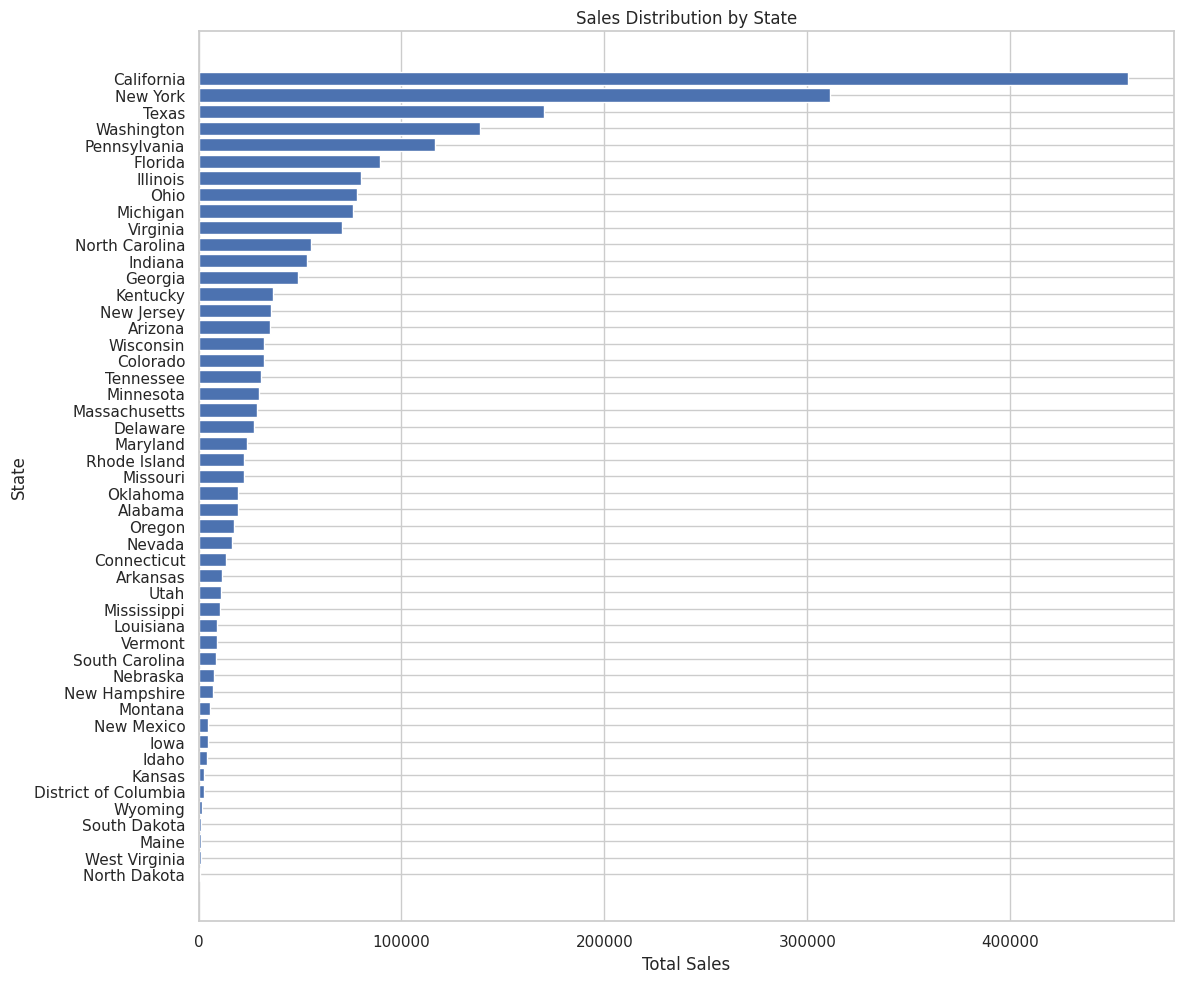

In [14]:
sales_state = (
    df.groupby("State", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=True)
)

plt.figure(figsize=(12, 10))

plt.barh(
    sales_state["State"],
    sales_state["Sales"]
)

plt.title("Sales Distribution by State")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Data Visualization with Seaborn

                                          Product Name      Sales
404              Canon imageCLASS 2200 Advanced Copier  61599.824
650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
786       HON 5400 Series Task Chairs for Big and Tall  21870.576
686         GBC DocuBind TL300 Electric Binding System  19823.479
688   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
805               Hewlett Packard LaserJet 3310 Copier  18839.686
787  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
683          GBC DocuBind P400 Electric Binding System  17965.068
813        High Speed Automatic Electric Letter Opener  17030.312


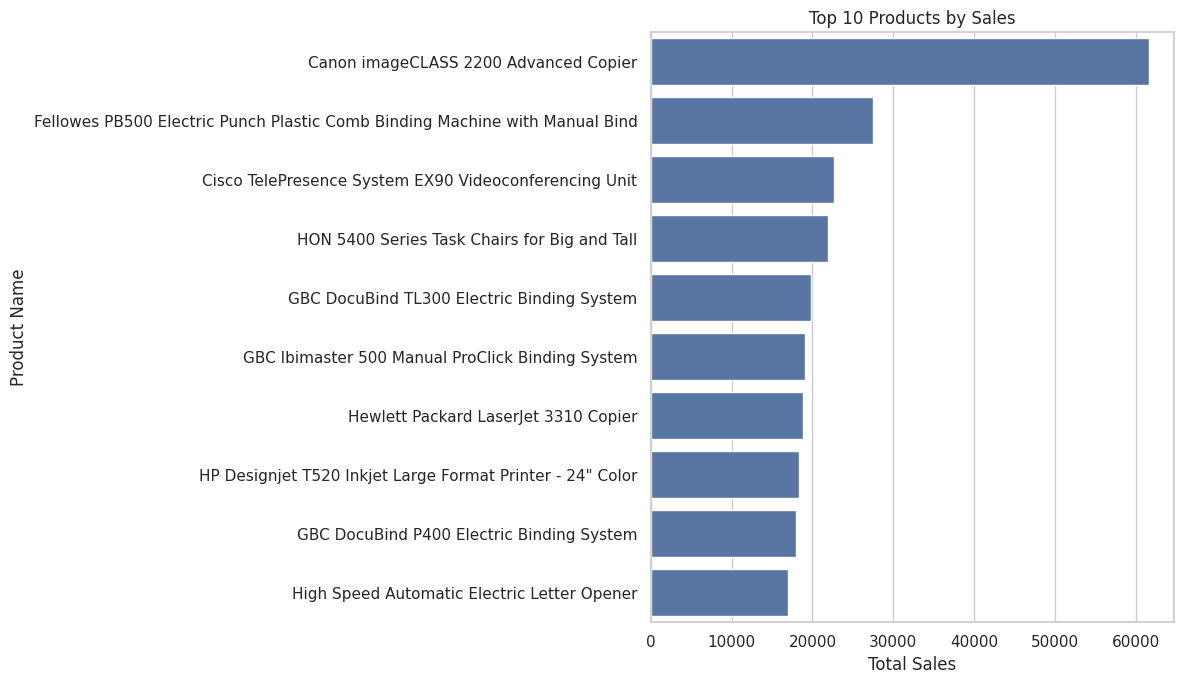

In [15]:
top_products = (
    df.groupby("Product Name", as_index=False)["Sales"]
      .sum()
      .sort_values("Sales", ascending=False)
      .head(10)
)

print(top_products)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="Sales",
    y="Product Name"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

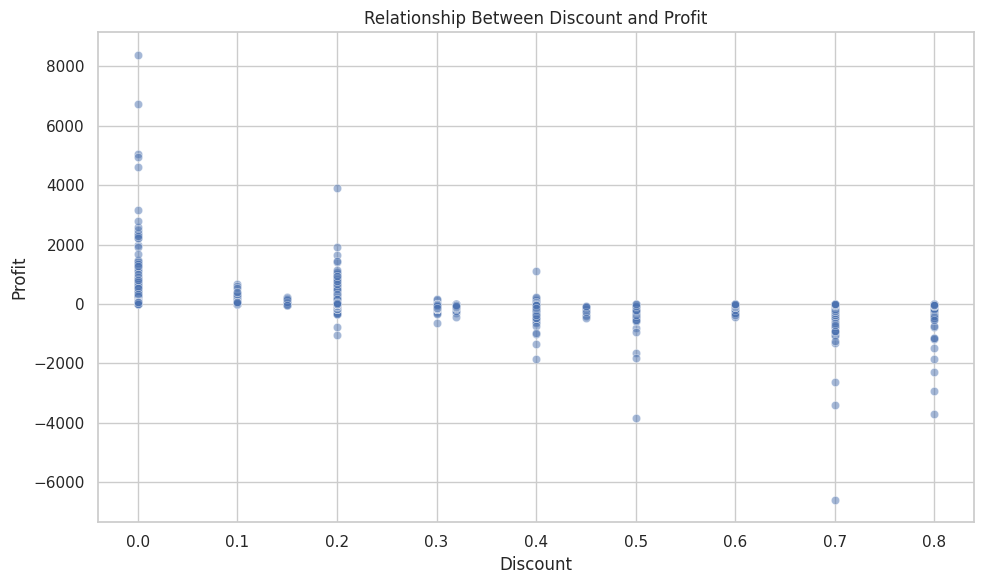

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

Comparative Analysis

**Comparison Between Matplotlib and Seaborn**

*Matplotlib*

Advantages

Highly customizable
Ideal for interactive charts
Gives complete control over every aspect of the visualization

Disadvantages

Requires more code
Default appearance is less visually appealing

*Seaborn*

Advantages

Attractive default styling
Less code required
Excellent for statistical visualizations

Disadvantages

Less flexible than Matplotlib
Built on top of Matplotlib, so some advanced customization still requires Matplotlib

Insights
Sales Trend

Sales generally increase over time, indicating business growth.

Top Products

A small number of products generate a disproportionately large percentage of total sales.

Profit vs Discount

Higher discounts often correspond to lower profits, suggesting excessive discounting reduces profitability.

Sales by State

Sales vary significantly between states, with several states contributing much more revenue than others.

**Conclusion**

Both Matplotlib and Seaborn can be used to visualize business data effectively. Matplotlib offers extensive customization and interactive capabilities, while Seaborn simplifies the creation of attractive statistical graphics. Together they provide valuable insights into sales performance, product popularity, profitability, and geographic sales distribution.